<a href="https://colab.research.google.com/github/sadberyy/CrisisAnalysis/blob/main/market_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Выбор фондового рынка для дальнейшего исследования

Если основываться на различные источники информации без детального анализа, выбор фондового рынка Германии обусловлен его характеристиками как развитого и диверсифицированного рынка, где исторически характерны более низкие значения попарных корреляций доходностей акций по сравнению с другими рынками.

**DAX** (Deutscher Aktienindex) - основной индекс, включает 40 крупнейших компаний (таких как Volkswagen, Siemens, SAP, Allianz). Это аналог американского Dow Jones.   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
plt.style.use('ggplot')

Выбираем акции по двум критериям:   
*   Минимальное количество пропусков
*   Это крупнейшие компании, представляющие все ключевые сектора экономики Германии. Их движение действительно двигает рынок и отражает общие настроения инвесторов



Промышленность и производство:   
*   Siemens AG (SIE) — Промышленный конгломерат, электроника, энергетика.
*   Volkswagen AG (VOW) — Автопроизводитель.
*   Daimler AG (MBG) — Автопроизводитель (Mercedes-Benz).
*   BMW AG (BMW) — Автопроизводитель.
*   ThyssenKrupp AG (TKA) — Сталелитейная и промышленная компания.
*   Deutsche Lufthansa AG (LHA) — Авиаперевозчик.
*   Deutsche Post AG (DHL) — Почтовая и логистическая компания (владелец DHL).
   
   
Химическая и фармацевтическая промышленность:
*   BASF SE (BAS) — Крупнейший в мире химический концерн.
*   Bayer AG (BAYN) — Химико-фармацевтический концерн.
*   Merck KGaA (MRK) — Фармацевтическая и химическая компания.
*   Fresenius SE & Co. KGaA (FRE) — Здравоохранение, международная компания в области медицинских услуг.
*   Fresenius Medical Care AG & Co. KGaA (FME) — Специализируется на диализе (часто выделяется как отдельная компания, но тесно связана с Fresenius).
   
   
Финансовый сектор:
*   Allianz SE (ALV) — Страховая компания, один из крупнейших финансовых конгломератов.
*   Münchener Rückversicherungs-Gesellschaft AG (MUV2) — Перестраховочная компания (Munich Re).
*   Deutsche Bank AG (DBK) — Крупнейший банк Германии.
*   Commerzbank AG (CBK) — Второй по величине банк Германии.
   
   
Ритейл и потребительские товары:
*   Adidas AG (ADS) — Производитель спортивной одежды и обуви.
*   Beiersdorf AG (BEI) — Производитель товаров для ухода (Nivea, etc.).
*   Henkel(HEN3) — крупный немецкий производитель товаров для дома и косметики (Persil, Schwarzkopf).
   
   
Технологии и телекоммуникации:
*   SAP SE (SAP) — Разработчик программного обеспечения, крупнейшая техкомпания Европы.
*   Deutsche Telekom AG (DTE) — Телекоммуникационный гигант.
*   Infineon Technologies AG (IFX) — Производитель полупроводников.
   
   
Энергетика и коммунальные услуги:
*   E.ON SE (EOAN) — Энергетическая компания.
*   RWE AG (RWE) — Энергетическая компания.
   
   
Прочее:
*   Continental AG (CON) — Производитель шин и автомобильных компонентов.

In [3]:
tickers = [
    'SIE', 'VOW', 'MBG', 'BMW', 'TKA', 'DHL',
    'LHA', 'BAS', 'BAYN', 'MRK', 'FRE', 'FME',
    'ALV', 'MUV2', 'DBK', 'CBK', 'ADS', 'BEI',
    'HEN3', 'SAP', 'DTE', 'IFX', 'EOAN', 'RWE', 'CON'
]
tickers = [ticker + '.DE' for ticker in tickers]
initial_df = yf.download(tickers, start='2006-01-01', end='2013-01-01', auto_adjust=True)['Close']
initial_df.head(5)

[*********************100%***********************]  25 of 25 completed


Ticker,ADS.DE,ALV.DE,BAS.DE,BAYN.DE,BEI.DE,BMW.DE,CBK.DE,CON.DE,DBK.DE,DHL.DE,...,IFX.DE,LHA.DE,MBG.DE,MRK.DE,MUV2.DE,RWE.DE,SAP.DE,SIE.DE,TKA.DE,VOW.DE
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-02,32.206352,52.764484,12.929646,20.308403,26.600300,17.677635,175.768204,42.895626,39.732327,18.917521,...,5.661222,5.231544,12.339637,25.860998,45.952591,27.735470,27.469393,32.176350,12.500366,23.613802
2006-01-03,32.477024,53.234688,12.744167,20.684692,27.111210,17.587835,177.309448,42.759140,39.640194,19.071764,...,5.675831,5.277360,12.364958,25.779982,46.092316,27.686836,27.383324,32.167530,12.786053,24.137390
2006-01-04,32.951683,54.522617,12.574643,20.736004,27.093420,17.701271,178.649673,42.565792,40.479168,19.226009,...,5.843842,5.348170,12.421227,25.776293,45.752972,27.876955,27.637920,33.239483,13.183223,23.927956
2006-01-05,32.853607,54.706615,12.674365,20.593468,26.994293,17.635098,176.773361,43.475677,40.493710,19.071764,...,5.982635,5.314847,12.407155,25.625326,45.505444,27.585142,28.403502,32.992458,13.183223,23.671398
2006-01-06,32.808506,55.438499,12.622510,20.559259,27.065456,17.857244,174.964081,44.209282,40.852581,19.543570,...,6.150643,5.414814,12.401531,25.684237,45.353729,27.479029,28.624035,33.146854,13.273803,23.744701


In [4]:
df = pd.DataFrame([initial_df.iloc[row] / initial_df.iloc[row-1] for row in range(1, initial_df.shape[0])], index=initial_df.index[1:]) # расчет доходностей
df = np.log(df) # логарифмические доходности
df.dropna(inplace=True, axis=0)
df.head()

Ticker,ADS.DE,ALV.DE,BAS.DE,BAYN.DE,BEI.DE,BMW.DE,CBK.DE,CON.DE,DBK.DE,DHL.DE,...,IFX.DE,LHA.DE,MBG.DE,MRK.DE,MUV2.DE,RWE.DE,SAP.DE,SIE.DE,TKA.DE,VOW.DE
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-03,0.008369,0.008872,-0.014449,0.018359,0.019025,-0.005093,0.008730,-0.003187,-0.002322,0.008120,...,0.002577,0.008720,0.002050,-0.003138,0.003036,-0.001755,-0.003138,-0.000274,0.022597,0.021931
2006-01-04,0.014509,0.023905,-0.013391,0.002478,-0.000656,0.006429,0.007530,-0.004532,0.020944,0.008055,...,0.029171,0.013329,0.004540,-0.000143,-0.007390,0.006843,0.009255,0.032781,0.030590,-0.008715
2006-01-05,-0.002981,0.003369,0.007899,-0.006898,-0.003665,-0.003745,-0.010558,0.021151,0.000359,-0.008055,...,0.023473,-0.006250,-0.001134,-0.005874,-0.005425,-0.010523,0.027324,-0.007459,0.000000,-0.010780
2006-01-06,-0.001374,0.013290,-0.004100,-0.001663,0.002633,0.012518,-0.010288,0.016733,0.008823,0.024437,...,0.027696,0.018634,-0.000453,0.002296,-0.003340,-0.003854,0.007734,0.004669,0.006847,0.003092
2006-01-09,-0.011001,-0.005102,-0.006340,-0.000277,-0.002162,-0.002650,0.001531,0.005260,0.003673,-0.004653,...,-0.008348,0.022815,0.021323,-0.000717,-0.006181,-0.001288,0.007985,-0.005606,-0.000525,0.010311


In [5]:
pd.set_option('display.width', 400)
pd.set_option('display.max_columns', 26)
corr_list = []

for year in range(2006, 2013):
  curr_year_df = df[df.index.year == year]
  year_corr = curr_year_df.corr() # выводим корреляционные матрицы
  corr_list.append(year_corr.where(np.triu(np.ones(year_corr.shape), k=1).astype(bool))) # сохраняем верхний треугольник для гистограммы
  print(f'{'-'*125}YEAR {year}{'-'*125}')
  print(f'{year_corr}\n')

-----------------------------------------------------------------------------------------------------------------------------YEAR 2006-----------------------------------------------------------------------------------------------------------------------------
Ticker     ADS.DE    ALV.DE    BAS.DE   BAYN.DE    BEI.DE    BMW.DE    CBK.DE    CON.DE    DBK.DE    DHL.DE    DTE.DE   EOAN.DE    FME.DE    FRE.DE   HEN3.DE    IFX.DE    LHA.DE    MBG.DE    MRK.DE   MUV2.DE    RWE.DE    SAP.DE    SIE.DE    TKA.DE    VOW.DE
Ticker                                                                                                                                                                                                                                                           
ADS.DE   1.000000  0.476142  0.387083  0.365719  0.401000  0.385734  0.345008  0.417696  0.477925  0.253355  0.286372  0.361602  0.347171  0.296589  0.255480  0.351128  0.325767  0.398447  0.306250  0.473643  0.273499  0.358

Коэффициенты корреляций оказались не такими низкими, как ожидалось. Рассмотрим их гистограмму:

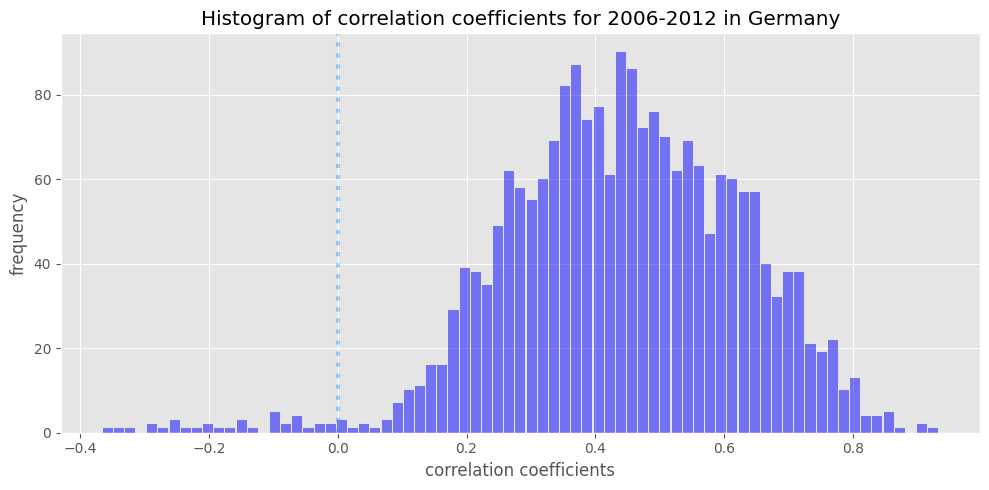

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.array(corr_list).flatten(), bins=75, color='#0000FF', rwidth=0.9, alpha=0.5)
ax.axvline(x=0, color='#1E90FF', linestyle=':', linewidth=3, alpha=0.4)
plt.xlabel('correlation coefficients', fontsize=12)
plt.ylabel('frequency', fontsize=12)
plt.title('Histogram of correlation coefficients for 2006-2012 in Germany')
plt.tight_layout()
plt.show()

Стоит пересмотреть свой выбор рынка и оценить ситуацию на других рынках - возможно, они имеют более низкое значение пика.

In [7]:
def get_avg_correlations(tickers, start, end): # расчет средних корреляций
    prices = yf.download(tickers, start=start, end=end, auto_adjust=True)['Close']
    log_returns = np.log(prices / prices.shift(1)).dropna()

    avg_corrs = []
    years = []

    for year in range(2005, 2020):
        year_data = log_returns[log_returns.index.year == year]
        corr_mat = year_data.corr()
        upper_tri = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
        avg_corr = upper_tri.stack().mean()
        avg_corrs.append(avg_corr)
        years.append(year)

    return years, avg_corrs

График для сравнения рынков разных стран:

[*********************100%***********************]  25 of 25 completed
[*********************100%***********************]  24 of 24 completed
[*********************100%***********************]  24 of 24 completed
[*********************100%***********************]  24 of 24 completed
[*********************100%***********************]  20 of 20 completed


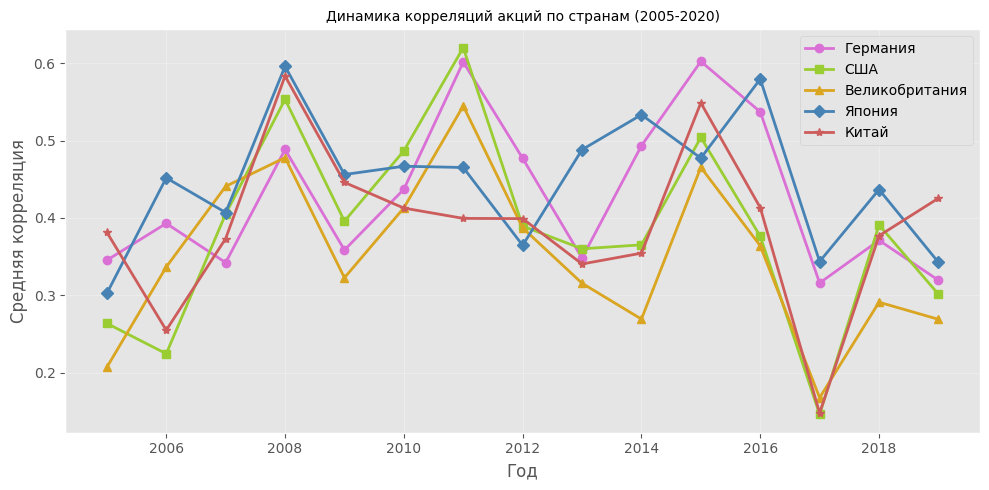

In [8]:
de_tickers = ['SIE.DE', 'VOW.DE', 'MBG.DE', 'BMW.DE', 'TKA.DE', 'DHL.DE',
              'LHA.DE', 'BAS.DE', 'BAYN.DE', 'MRK.DE', 'FRE.DE', 'FME.DE',
              'ALV.DE', 'MUV2.DE', 'DBK.DE', 'CBK.DE', 'ADS.DE', 'BEI.DE',
              'HEN3.DE', 'SAP.DE', 'DTE.DE', 'IFX.DE', 'EOAN.DE', 'RWE.DE', 'CON.DE']

us_tickers = ['GE', 'F', 'NUE', 'UPS', 'DD', 'PFE', 'JNJ', 'DVA',
              'BRK-B', 'AIG', 'C', 'BAC', 'NKE', 'PG', 'CL', 'MSFT',
              'T', 'INTC', 'XOM', 'CVX', 'BWA', 'WMT', 'KO', 'MCD']

uk_tickers = ['BP', 'SHEL.L', 'HSBA.L', 'LLOY.L', 'BARC.L', 'ANTO.L', 'RIO.L',
              'AAL.L', 'ULVR.L', 'DGE.L', 'AZN.L', 'GSK.L', 'VOD.L', 'TSCO.L',
              'RR.L', 'PRU.L', 'AV.L', 'LSEG.L', 'REL.L', 'ABF.L',
              'SBRY.L', 'STAN.L', 'LGEN.L', 'III.L']

jp_tickers = ['7203.T', '7267.T', '7201.T', '6954.T', '6758.T', '6702.T',
              '6501.T', '6971.T', '8316.T', '8411.T', '7751.T',
              '6752.T', '4502.T', '4503.T', '8058.T', '8031.T', '9501.T',
              '9983.T', '8267.T', '9432.T', '7011.T', '7731.T', '7733.T','6504.T']

cn_tickers = [
    '000002.SZ', '000063.SZ', '000858.SZ', '600000.SS', '600011.SS',
    '600016.SS', '600019.SS', '600028.SS', '600029.SS', '600030.SS',
    '600036.SS', '600050.SS', '600104.SS', '600115.SS', '600887.SS',
    '600188.SS', '600256.SS', '600406.SS', '600519.SS', '600690.SS'
]
years_data = {}
corrs_data = {}

countries = [
    ('Германия', de_tickers),
    ('США', us_tickers),
    ('Великобритания', uk_tickers),
    ('Япония', jp_tickers),
    ('Китай', cn_tickers)
]
colors = {
    'Германия': '#DA70D6',
    'США': '#9ACD32',
    'Великобритания': '#DAA520',
    'Япония': '#4682B4',
    'Китай': '#CD5C5C'
}
markers = {
    'Германия': 'o',
    'США': 's',
    'Великобритания': '^',
    'Япония': 'D',
    'Китай': '*'
}

for name, tickers in countries:
    years, corrs = get_avg_correlations(tickers, '2005-01-01', '2020-01-01')
    if years and corrs:
        years_data[name] = years
        corrs_data[name] = corrs

plt.figure(figsize=(10, 5))

for name in years_data:
    plt.plot(years_data[name], corrs_data[name],
             marker=markers[name], linestyle='-', linewidth=2, markersize=6,
             label=name, color=colors[name])

plt.xlabel('Год', fontsize=12)
plt.ylabel('Средняя корреляция', fontsize=12)
plt.title('Динамика корреляций акций по странам (2005-2020)', fontsize=10)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Но средняя корреляция для 25 случайно выбранных акций - не самый надежный показатель для выбора рынка. Чтобы выбор рынка был более обоснованным, рассмотрим среди 25 акций каждого рынка 10 акций с наиболее низкой корреляцией.
Также, 10 акций проще визуализировать в дальнейших результатах, нежели 25 штук.

In [9]:
# вычисление пика распределения за весь период наблюдений
def get_peak_correlation(tickers, start='2006-01-01', end='2013-01-01', bins=75):
    prices = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)['Close']

    # логарифмические доходности
    df = pd.DataFrame([prices.iloc[row] / prices.iloc[row-1] for row in range(1, prices.shape[0])],
                      index=prices.index[1:])
    df = np.log(df)
    df.dropna(inplace=True, axis=0)

    # все корреляции за все годы
    corr_list = []
    for year in range(2006, 2013):
        curr_year_df = df[df.index.year == year]
        if len(curr_year_df) > 0:
            year_corr = curr_year_df.corr()
            corr_list.append(year_corr.where(np.triu(np.ones(year_corr.shape), k=1).astype(bool)))

    all_corrs = np.array(corr_list).flatten()
    all_corrs_clean = all_corrs[~np.isnan(all_corrs)]

    # пик распределения
    hist, bin_edges = np.histogram(all_corrs_clean, bins=bins)
    peak_bin = np.argmax(hist)
    peak = bin_edges[peak_bin]

    return peak

In [10]:
# 10 самых низкокоррелированных акций за все года
def get_top_10_low_correlated(tickers, start='2006-01-01', end='2013-01-01'):
    prices = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)['Close']

    # логарифмические доходности
    df = pd.DataFrame([prices.iloc[row] / prices.iloc[row-1] for row in range(1, prices.shape[0])],
                      index=prices.index[1:])
    df = np.log(df)
    df.dropna(inplace=True, axis=0)

    # средняя абсолютная корреляция для каждой акции
    all_abs_corrs = {asset: [] for asset in tickers}
    for year in df.index.year.unique():
        df_year = df[df.index.year == year]
        corr_year = df_year.corr()

        for asset in tickers:
            corr_series = corr_year[asset].drop(asset, errors='ignore')
            all_abs_corrs[asset].extend(corr_series.abs().tolist())

    avg_corrs = {}
    for asset in tickers:
        avg_corrs[asset] = np.mean(all_abs_corrs[asset])

    # берём топ-10
    sorted_assets = sorted(avg_corrs.items(), key=lambda x: x[1])
    top_10 = [asset for asset, i in sorted_assets[:10]]

    return top_10

In [11]:
markets_25 = {
    'ФРГ': de_tickers,
    'США': us_tickers,
    'Великобритания': uk_tickers,
    'Япония': jp_tickers,
    'Китай': cn_tickers
}

peaks_25 = {}

for name, tickers in markets_25.items():
  peak = get_peak_correlation(tickers)
  peaks_25[name] = peak

In [12]:
print("\n" + "-"*145)
print("Топ-10 низкокоррелированных акций по рынкам")
print("-"*145)

peaks_top10 = {}

for name, tickers in markets_25.items():
  top_10 = get_top_10_low_correlated(tickers)
  peak = get_peak_correlation(top_10)
  peaks_top10[name] = peak
  print(f"Для {name} топ-10 акций: {top_10}")


-------------------------------------------------------------------------------------------------------------------------------------------------
Топ-10 низкокоррелированных акций по рынкам
-------------------------------------------------------------------------------------------------------------------------------------------------
Для ФРГ топ-10 акций: ['FME.DE', 'FRE.DE', 'MRK.DE', 'VOW.DE', 'BEI.DE', 'IFX.DE', 'HEN3.DE', 'DTE.DE', 'SAP.DE', 'ADS.DE']
Для США топ-10 акций: ['DVA', 'WMT', 'F', 'CL', 'BRK-B', 'AIG', 'MCD', 'NKE', 'PG', 'BWA']
Для Великобритания топ-10 акций: ['BP', 'GSK.L', 'TSCO.L', 'VOD.L', 'SBRY.L', 'AZN.L', 'ABF.L', 'LSEG.L', 'ULVR.L', 'REL.L']
Для Япония топ-10 акций: ['9501.T', '9432.T', '9983.T', '4503.T', '4502.T', '7733.T', '8267.T', '6504.T', '7731.T', '6501.T']
Для Китай топ-10 акций: ['600519.SS', '600406.SS', '600887.SS', '000063.SZ', '600256.SS', '600011.SS', '600115.SS', '600690.SS', '000858.SZ', '600104.SS']


In [13]:
print("\n" + "="*65)
print(" "*10, "Сводная таблица для пиков распределений")
print("="*65)
print(f"{'Рынок':<20} {'25 акций':<15} {'Топ-10 низкокоррелированных':<30}")
print("-"*65)

for name in markets_25.keys():
    peak_25 = peaks_25.get(name, float('nan'))
    peak_top10 = peaks_top10.get(name, float('nan'))
    print(f"{name:<20} {peak_25:<15.6f} {peak_top10:<30.6f}")


           Сводная таблица для пиков распределений
Рынок                25 акций        Топ-10 низкокоррелированных   
-----------------------------------------------------------------
ФРГ                  0.431120        0.246802                      
США                  0.466651        0.389618                      
Великобритания       0.434131        0.435029                      
Япония               0.454788        0.480793                      
Китай                0.253336        0.399192                      


В дальнейших тестах будет использоваться статистика вида
   
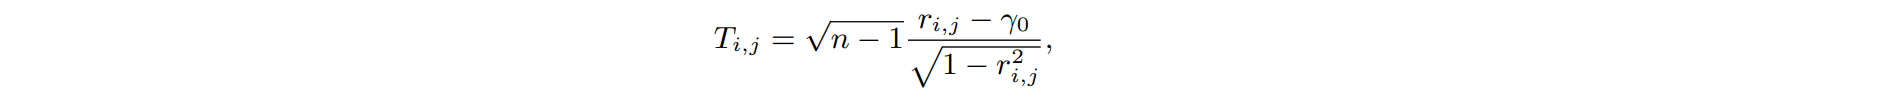  
    
где gamma0 - пороговый коэффициент, близкий к пику, r_ij - выборочный коэффициент корреляции Пирсона. При gamma0 близком к нулю статистика имеет асимптотически стандартное нормальное распределение N(0,1), причем чем ближе gamma0 к нулю, тем лучше качество этого приближения. Также, малое значение gamma0 отображает реальную картину - инвесторы строят диверсифицированные портфели, состоящие из пар акций с наиболее низкими корреляциями.


Ниже всех корреляции у рынка Германии. Также, для для репрезентативности будущих результатов метода обнаружения динамики **было принято решение выбрать 10 акций ФРГ**.